# DicomSDL basic tutorial

This notebook adapts the original DicomSDL `basic1.ipynb` tutorial to the current Python API.
The overall flow is the same: open a sample file, inspect pixel data, preview an image, dump part of the dataset, and read a few metadata values in different ways.

In [1]:
import dicomsdl as dicom

### Open a sample file

`dicom.read_file(...)` returns a `DicomFile`, which owns the root dataset and forwards the most common metadata helpers.
The sample file `CT2_JLSN` is included in this local `tutorials/` directory, so the notebook can open it directly.

In [2]:
df = dicom.read_file("CT2_JLSN")  # file is available at ftp://medical.nema.org/MEDICAL/Dicom/DataSets/WG04
df

DicomFile(path='CT2_JLSN')

### Decode pixel samples into a NumPy array

`df.to_array()` decodes Pixel Data into a NumPy array, which is usually the part most image-processing users care about.
Install the `numpy` extra if you want to run this cell locally.

In [3]:
df.to_array()

array([[-2050, -2050, -2050, ..., -2045, -2045, -2045],
       [-2050, -2050, -2050, ..., -2049, -2049, -2049],
       [-2050, -2050, -2050, ..., -2047, -2047, -2047],
       ...,
       [-2044, -2044, -2044, ..., -2048, -2048, -2048],
       [-2044, -2044, -2044, ..., -2048, -2048, -2048],
       [-2044, -2044, -2044, ..., -2046, -2046, -2046]],
      shape=(512, 512), dtype=int16)

### Quick image preview with Pillow

`df.to_pil_image(frame=0)` returns a Pillow image object for a quick preview.
You can display it in the notebook, or save it to formats that Pillow supports.
Install the `pil` extra if you want to run this cell locally.

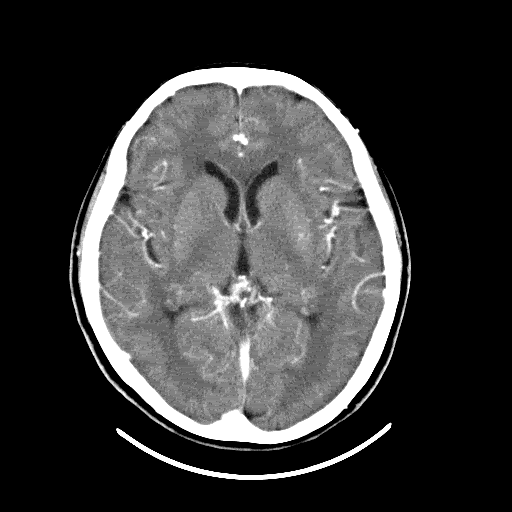

In [4]:
df.to_pil_image(frame=0)

### Create a decode plan and inspect the output layout

`create_decode_plan()` is the main way to inspect the decoded output layout before you decode into your own buffer.
This small summary is a quick replacement for the older `getPixelDataInfo()`-style tutorial step.

In [5]:
# Build one DecodePlan so we can inspect the decoded output contract.
plan = df.create_decode_plan()
{
    "rows": plan.rows,
    "cols": plan.cols,
    "frames": plan.frames,
    "samples_per_pixel": plan.samples_per_pixel,
    "bits_stored": plan.bits_stored,
    "dtype": str(plan.dtype),
}


{'rows': 512,
 'cols': 512,
 'frames': 1,
 'samples_per_pixel': 1,
 'bits_stored': 16,
 'dtype': 'int16'}

### Print a shortened dataset dump

`df.dump(...)` returns a textual dump of the dataset.
Each line corresponds to one `DataElement`, so it is a convenient way to discover tags, keywords, and representative values before you write more targeted lookup code.
Here we print only the first part so the notebook stays readable on GitHub and in Jupyter.

In [6]:
# Show only the first part of the dump to keep the notebook compact.
print(df.dump(max_print_chars=80, include_offset=False)[:2000] + " ...")

TAG	VR	LEN	VM	VALUE	KEYWORD
'00020000'	UL	4	1	192                                                                             	# FileMetaInformationGroupLength
'00020001'	OB	2	1	'\x00\x01'                                                                      	# FileMetaInformationVersion
'00020002'	UI	26	1	'1.2.840.10008.5.1.4.1.1.2' = CT Image Storage                                  	# MediaStorageSOPClassUID
'00020003'	UI	46	1	'1.3.6.1.4.1.5962.1.1.2.1.7.20040826185059.5457'                                	# MediaStorageSOPInstanceUID
'00020010'	UI	22	1	'1.2.840.10008.1.2.4.81' = JPEG-LS Lossy (Near-Lossless) Image Compression      	# TransferSyntaxUID
'00020012'	UI	18	1	'1.3.6.1.4.1.5962.2'                                                            	# ImplementationClassUID
'00020013'	SH	10	1	'DCTOOL100'                                                                     	# ImplementationVersionName
'00020016'	AE	8	1	'CLUNIE1'                                                         

### Read values in a few different ways

From the dump above, you can see that `(0008,0020)` / `StudyDate` is present.
The same metadata value can be reached through several APIs, and you can choose the style that reads best for your code.
This notebook shows attribute access, `DataElement` access through `[]`, packed integer lookup, and the named `get_dataelement(...)` form.

In [7]:
print(df.StudyDate)
print(df["StudyDate"].value)
print(df[0x00080020].value)
print(df.get_dataelement("StudyDate").value)

20040826
20040826
20040826
20040826


### Attribute access works well for standard keywords

For ordinary top-level standard DICOM keywords, attribute access is usually the cleanest path in Python.
If the `DicomFile` does not currently contain a data element for a known DICOM keyword, attribute access returns `None`.
Unknown keywords still raise `AttributeError`, so normal typos stay visible.
This also makes it easy to read several values in a compact style.

In [8]:
print(df.PatientName)
print(df.Rows, df.Columns)
print(df.InstitutionAddress)

PersonName(CompressedSamples^CT2)
512 512
None


In [9]:
df.InstitutionTypoErro

AttributeError: DataSet has no attribute 'InstitutionTypoErro'

### Read a multilingual Person Name

This sample switches to a file that declares a character set and stores `PatientName` in multiple representation groups.

In [10]:
df = dicom.read_file("SCSI2")  # file is available at http://www.dclunie.com/images/charset/index.html

The next cell shows the combined `PersonName(...)` value exactly as DicomSDL presents it.

In [11]:
df.PatientName

PersonName(Hong^Gildong=洪^吉洞=홍^길동)

The following cell breaks the same value into its alphabetic, ideographic, and phonetic components.

In [13]:
df.PatientName.alphabetic, df.PatientName.ideographic, df.PatientName.phonetic

(PersonNameGroup(Hong^Gildong), PersonNameGroup(洪^吉洞), PersonNameGroup(홍^길동))

In [17]:
' '.join(df.PatientName.alphabetic.components).strip(), ' '.join(df.PatientName.ideographic.components).strip(), ' '.join(df.PatientName.phonetic.components).strip()

('Hong Gildong', '洪 吉洞', '홍 길동')